# 02 — Regression: Maternal Age and Child Intelligence

Simple linear regression of maternal age against PPVT and IQ scores, with scatterplots, residual plots, and Q-Q plots to check model assumptions.

Following the analysis of relationship between maternal education and child intelligence in both datasets, we investigated the involvement of mom's age in child intelligence independently using tests for linearity. 

## Regression analysis of Mom's Age and Child Intelligence

### Linear Regression for mom_age and PPVT scores

In [1]:
import pandas as pd
import statsmodels.api as sm #statsmodel is better for regression analysis

# Load your dataset
df = pd.read_csv('../data/child_iq_outliers_removed.csv')

# Define your predictor and response variable
X = df[['mom age (childbirth age)']]
y = df['ppvt (child test score)']

# Add a constant for the intercept
X = sm.add_constant(X)

# Fit the simple linear regression model
model = sm.OLS(y, X).fit()

# Print the summary of the regression model
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     ppvt (child test score)   R-squared:                       0.029
Model:                                 OLS   Adj. R-squared:                  0.026
Method:                      Least Squares   F-statistic:                     11.21
Date:                     Mon, 17 Aug 2026   Prob (F-statistic):           0.000896
Time:                             19:58:14   Log-Likelihood:                -1664.5
No. Observations:                      382   AIC:                             3333.
Df Residuals:                          380   BIC:                             3341.
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

Major evaluation points: 

- Weak linear relationship between mom's age and ppvt scores  - low R-squared value

- Statistical significance suggested for the model as a whole - p-value of 0.000896

- Statistical significance for positive association between maternal age and child test scores - p-value of 0.001

The R-squared value of 0.029 indicates that only 2.9% of the variation of PPVT scores are accounted for by the age of the mother. Supplemented with a high standard error value of 8.428, these numbers indicate the presence of other confounding variables not included in this model acting as predictors of ppvt scores. 

### Linear Regression for mom_age and kid_iq scores

In [2]:
import pandas as pd
import statsmodels.api as sm

# Load your dataset
df = pd.read_csv('../data/kid_iq_outliers_removed.csv')

# Define your predictors and response variable
X = df['mom_age  (age of childbirth)']
y = df['kid_score (IQ score)']  

# Add a constant for the intercept
X = sm.add_constant(X)

# Fit the multiple regression model
model = sm.OLS(y, X).fit()

# Print the summary of the regression model
print(model.summary())


                             OLS Regression Results                             
Dep. Variable:     kid_score (IQ score)   R-squared:                       0.007
Model:                              OLS   Adj. R-squared:                  0.005
Method:                   Least Squares   F-statistic:                     3.244
Date:                  Mon, 17 Aug 2026   Prob (F-statistic):             0.0724
Time:                          19:58:15   Log-Likelihood:                -1907.9
No. Observations:                   432   AIC:                             3820.
Df Residuals:                       430   BIC:                             3828.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

Major evaluation points:

- Weak linear relationship between mom's age and child IQ - low R-squared value

- No statistical significance seen for the model - p-value>0.05

The R-squared value of 0.007 suggests that only 7% of the variation in child IQ is accounted for by mother's age. Supplemented with a high standard error value of 8.205, these numbers indicate the presence of other confounding variables not included in this model acting as predictors of child IQ.

Now, we visualise the linear relationship between mothers' age with child intelligence in both datasets using scatterplots as both variables are continuous. 

Slope ppvt: 1.236743547003481, Intercept ppvt: 59.85212333400749, Correlation ppvt: 0.16925481774624307
goodness of fit ppvt: 0.028647193330313958
Slope childiq: 0.6440720764101555, Intercept childiq: 72.10426533326677, Correlation childiq: 0.08652607903777408
goodness of fit childiq: 0.007486762353651128


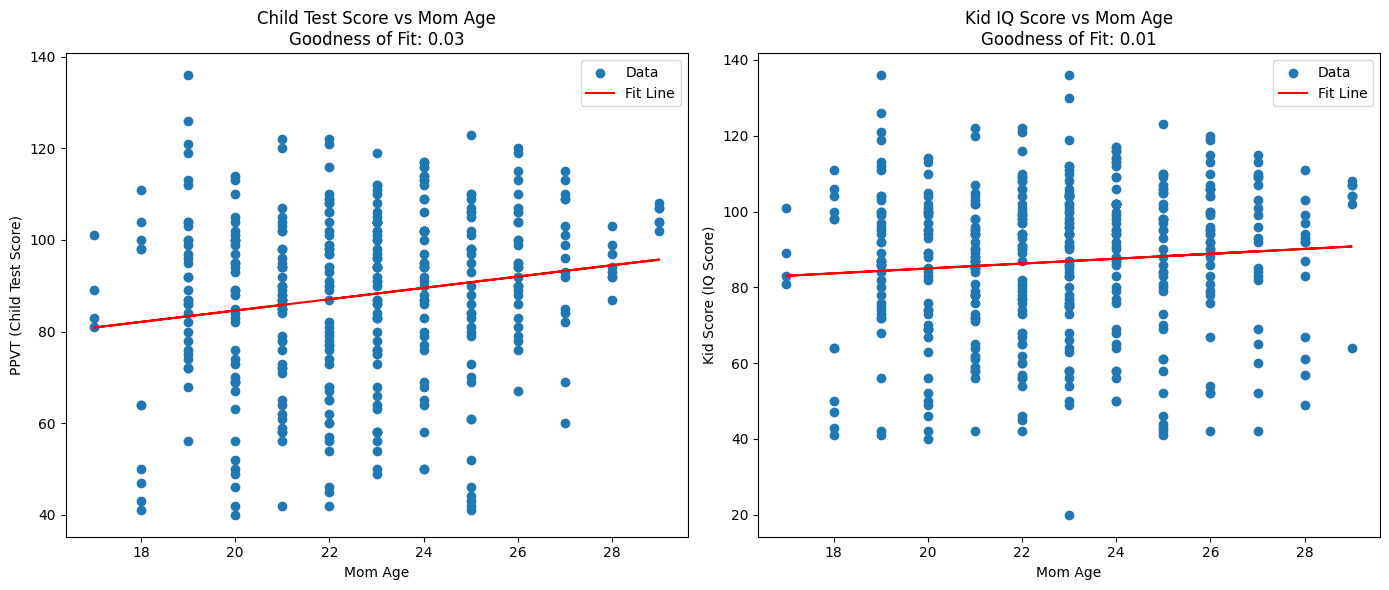

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load data
childData = pd.read_csv('../data/child_iq_outliers_removed.csv')
kidData = pd.read_csv('../data/kid_iq_outliers_removed.csv')


# Create a figure with 1 row and 2 columns for side-by-side scatterplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns, set figure size

# Scatterplot 1: Child test scores by Mothers' age
slope, intercept, r_value, _, _ = linregress(childData['mom age (childbirth age)'], childData['ppvt (child test score)'])
goodnessoffit1 = r_value * r_value
print(f"Slope ppvt: {slope}, Intercept ppvt: {intercept}, Correlation ppvt: {r_value}")
print(f"goodness of fit ppvt: {goodnessoffit1}")
axes[0].scatter(childData['mom age (childbirth age)'], childData['ppvt (child test score)'], label='Data')
axes[0].plot(childData['mom age (childbirth age)'], intercept + slope * childData['mom age (childbirth age)'], color='red', label='Fit Line')
axes[0].set_xlabel('Mom Age')
axes[0].set_ylabel('PPVT (Child Test Score)')
axes[0].set_title(f"Child Test Score vs Mom Age\nGoodness of Fit: {goodnessoffit1:.2f}")
axes[0].legend()

# Scatterplot 2: Kid IQ score by Mother's IQ
slope, intercept, r_value, _, _ = linregress(kidData['mom_age  (age of childbirth)'], kidData['kid_score (IQ score)'])
goodnessoffit2 = r_value * r_value
print(f"Slope childiq: {slope}, Intercept childiq: {intercept}, Correlation childiq: {r_value}")
print(f"goodness of fit childiq: {goodnessoffit2}")
axes[1].scatter(kidData['mom_age  (age of childbirth)'], kidData['kid_score (IQ score)'], label='Data')
axes[1].plot(kidData['mom_age  (age of childbirth)'], intercept + slope * kidData['mom_age  (age of childbirth)'], color='red', label='Fit Line')
axes[1].set_xlabel('Mom Age')
axes[1].set_ylabel('Kid Score (IQ Score)')
axes[1].set_title(f"Kid IQ Score vs Mom Age\nGoodness of Fit: {goodnessoffit2:.2f}")
axes[1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()



The line of best fit for the graph on the left shows a slight positive slope suggesting that with increase in mom's age at childbirth, the ppvt scores increase slightly. However this is a very weak correlation (as also seen by the results of linear regression). Additionally, the wide dispersion of data points suggest considerable variability in test scores for mothers of similar ages. The low value of the correlation coefficient (0.17) confirms these trends. Further, the goodness of fit value is calculated to indicate how well the regression line fits to the data - which is basically the same as R-squared value seen above.

The line of best fit for the graph on the right shows a smaller slope compared to the other graph suggesting an even slighter positive association. The lower value of correlation coefficient (0.09) also points towards a weaker positive relationship between the variables.

The following 2 blocks involving residual plots and Q-Q plots are used to approve the accuracy of the linear regression model chosen to analyse mom's age and child intelligence.

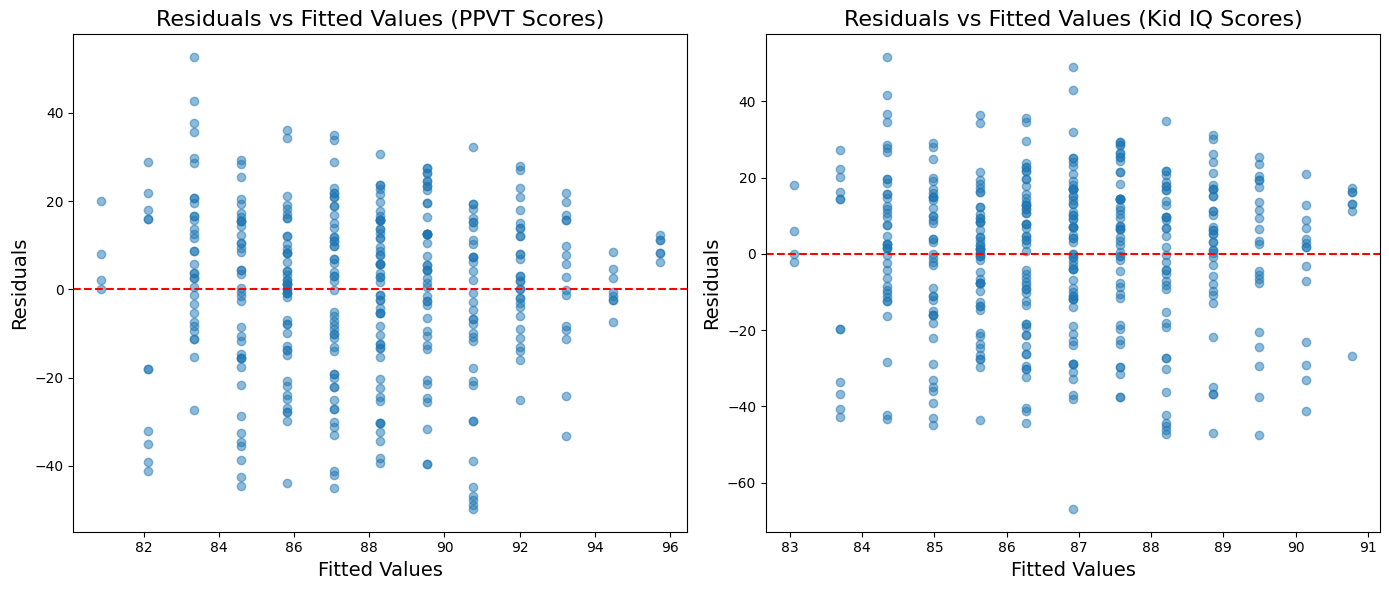

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load data
childData = pd.read_csv('../data/child_iq_outliers_removed.csv')
kidData = pd.read_csv('../data/kid_iq_outliers_removed.csv')

# Regression 1: Child test scores by Mother's age
slope1, intercept1, _, _, _ = linregress(childData['mom age (childbirth age)'], childData['ppvt (child test score)'])
childData['fittedvalues'] = intercept1 + slope1 * childData['mom age (childbirth age)']  # Fitted values
childData['residuals'] = childData['ppvt (child test score)'] - childData['fittedvalues']  # Residuals

# Regression 2: Kid IQ score by Mother's age
slope2, intercept2, _, _, _ = linregress(kidData['mom_age  (age of childbirth)'], kidData['kid_score (IQ score)'])
kidData['fittedvalues'] = intercept2 + slope2 * kidData['mom_age  (age of childbirth)']  # Fitted values
kidData['residuals'] = kidData['kid_score (IQ score)'] - kidData['fittedvalues']  # Residuals

# Create side-by-side residual plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# Residual plot 1: Child test scores by Mother's age
axes[0].scatter(childData['fittedvalues'], childData['residuals'], alpha=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')  # Horizontal line at 0
axes[0].set_xlabel("Fitted Values", fontsize=14)
axes[0].set_ylabel("Residuals", fontsize=14)
axes[0].set_title("Residuals vs Fitted Values (PPVT Scores)", fontsize=16)

# Residual plot 2: Kid IQ score by Mother's age
axes[1].scatter(kidData['fittedvalues'], kidData['residuals'], alpha=0.5)
axes[1].axhline(y=0, color='red', linestyle='--')  # Horizontal line at 0
axes[1].set_xlabel("Fitted Values", fontsize=14)
axes[1].set_ylabel("Residuals", fontsize=14)
axes[1].set_title("Residuals vs Fitted Values (Kid IQ Scores)", fontsize=16)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()


Residuals in both the plots displayed above are scattered around the red fitted line in a uniform pattern, which supports the assumption of minimal systemic bias in predictions by the linear regression model - supporting the accuracy of using a linear regression model to analyse mom's age and ppvt scores and kid IQ scores. 

However, we needed to account for the unusual banding and overlapping of data points in the residual vs fitted value plots, and for this, the counts for mother's ages in each dataset is computed below.

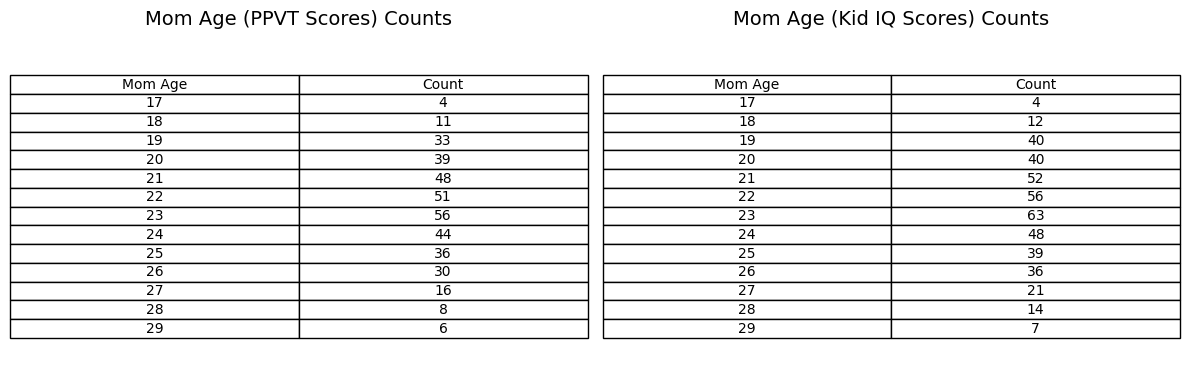

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
childData = pd.read_csv('../data/child_iq_outliers_removed.csv')
kidData = pd.read_csv('../data/kid_iq_outliers_removed.csv')

# Calculate the value counts for mom age (childbirth age) and sort by index
mom_age_count = childData['mom age (childbirth age)'].value_counts().sort_index()
mom_age_table = pd.DataFrame({
    "Mom Age": mom_age_count.index,
    "Count": mom_age_count.values
})

# Here, we create a second dataset
mom_age_count2 = kidData['mom_age  (age of childbirth)'].value_counts().sort_index()
mom_age_table2 = pd.DataFrame({
    "Mom Age": mom_age_count2.index,
    "Count": mom_age_count2.values
    
})

# Plot the two tables side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Table 1: Mom age count
axes[0].axis('tight')
axes[0].axis('off')
axes[0].table(cellText=mom_age_table.values,
              colLabels=mom_age_table.columns,
              cellLoc='center',
              loc='center')
axes[0].set_title("Mom Age (PPVT Scores) Counts", fontsize=14)

# Table 2: Additional table (replace with your real data)
axes[1].axis('tight')
axes[1].axis('off')
axes[1].table(cellText=mom_age_table2.values,
              colLabels=mom_age_table2.columns,
              cellLoc='center',
              loc='center')
axes[1].set_title("Mom Age (Kid IQ Scores) Counts", fontsize=14)

# Adjust layout
plt.tight_layout()
plt.show()


As evident above, both datasets contain certain age groups that contain more data than others - hence explaining the unusual banding in residual vs fitted value plots. Having acknowledged this, we continue with the analysis by visualising the residuals using Q-Q plots. 

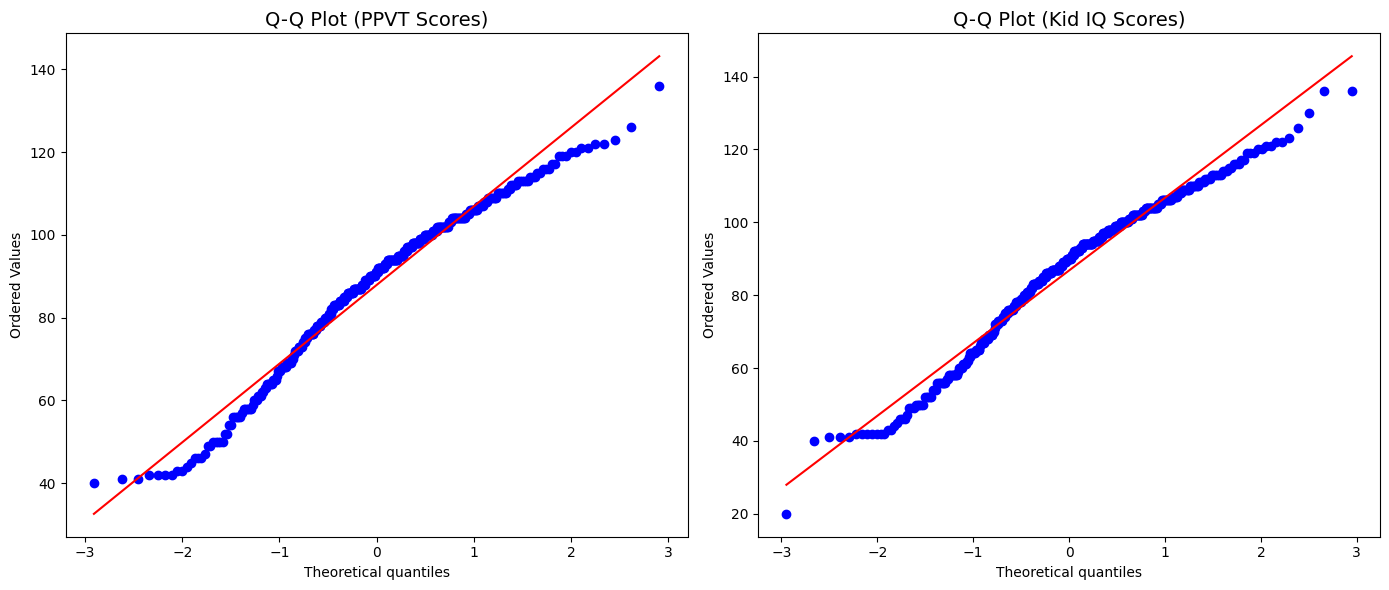

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load data
childData = pd.read_csv('../data/child_iq_outliers_removed.csv')
kidData = pd.read_csv('../data/kid_iq_outliers_removed.csv')

# Create side-by-side Q-Q plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# Q-Q plot 1: Child test scores (PPVT)
stats.probplot(childData['ppvt (child test score)'], dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot (PPVT Scores)", fontsize=14)

# Q-Q plot 2: Kid IQ scores
stats.probplot(kidData['kid_score (IQ score)'], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (Kid IQ Scores)", fontsize=14)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()


The Q-Q plots determines whether residuals of the linear regression model follow a normal distribution, as regression models often assume normality. Most of the points in the Q-Q plots above lie near the red dotted line, suggesting that the residual distribution is approximately normal and linear regression models for both mom age and ppvt scores and mom age and kid IQ scores show reliable results.

Overall, the residual vs fitted values plot and the Q-Q plot suggest that the predictions of the linear regression model on our data are reliable. This reinforces the idea of the weak correlation between mom age and child intelligence, therefore suggesting the requirement to consider other factors when investigating the influence of maternal characteristics in regard to child intelligence.

Thus, comprehensive analysis of the relationship between maternal age and child intelligence across both datasets reveals that despite maternal age influencing the DV, the extent of its influence is limited when isolated from other variables. Hence, the following blocks combine this factor with our first independent variable (maternal education) and investigate whether the combined effect is more influential for predicting child intelligence. 